In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [20]:
data_path = r".\dataset\insurance.csv"
df = pd.read_csv(data_path)


In [21]:
df_feat = df.copy()
df_feat.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# X = df_engineered.drop(columns=['log_charges', 'age', 'bmi', 'charges'])
# Y = df_engineered['log_charges']
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# stratify_cols = X['age_group'].astype(str) + '_' + \
#                 X['bmi_category'].astype(str) + '_' + \
#                 X['smoker'].astype(str)


# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True,
#     stratify=X['smoker']  # ← single argument!
# )

# category_selector = make_column_selector(pattern="cat")
# object_selector = make_column_selector(dtype_include=object)
# numerical_selector = ['children','bmi_risk','age_risk']

# preprocessing_pipeline = make_column_transformer(
#     (OneHotEncoder(handle_unknown="ignore"), category_selector),
#     (OneHotEncoder(handle_unknown="ignore"), object_selector),
#     (StandardScaler(), numerical_selector),
#     remainder="drop")

# model_pipeline = make_pipeline(
#     preprocessing_pipeline,
#     LinearRegression()
# )

# kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# results  = cross_validate(model_pipeline, X_train, y_train, cv=kfold,scoring='neg_mean_squared_error', return_estimator=True )
# print(results.keys())
# rmse_scores = np.sqrt(-results['test_score'])
# print(f"RMSE scores: {rmse_scores}")
# print(f"Mean RMSE: {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})")
# # Access feature names from first fold's estimator
# first_model = results['estimator'][0]
# sed_model = results['estimator'][1]
# feature_names = first_model.named_steps['columntransformer'].get_feature_names_out()
# print(f"Features: {feature_names}")


In [ ]:
X = df_feat.drop("charges", axis=1)
y = df_feat["charges"]

category_selector = make_column_selector(pattern="cat")
object_selector = make_column_selector(dtype_include=object)
numerical_selector = ['age', 'bmi', 'children']

preprocessing_pipeline = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), category_selector),
    (OneHotEncoder(handle_unknown="ignore"), object_selector),
    (StandardScaler(), numerical_selector),
    remainder="drop")

model_pipeline = make_pipeline(
    preprocessing_pipeline,
    LinearRegression()
)

In [ ]:
def linear_regression_diagnostics(dataframe, target, K=5):
    X = dataframe.drop(target, axis=1)
    y = dataframe[target]

    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    categorical_selector = make_column_selector(dtype_include=["object", "category"])
    numerical_selector = make_column_selector(dtype_include=np.number)

    # target_preprocessing_pipeline = make_column_transformer(
    #     (np.log1p, make_column_selector(target)),
    #     remainder="passthrough")

    preprocessing_pipeline = make_column_transformer(
        (OneHotEncoder(handle_unknown="ignore"), categorical_selector),
        (StandardScaler(), numerical_selector),
        remainder="drop")

    model_pipeline = make_pipeline(
        preprocessing_pipeline,
        # target_preprocessing_pipeline,
        LinearRegression()
    )

    model_pipeline.fit(x_train, y_train)

    y_pred = model_pipeline.predict(x_test)

    print("\nModel Performance")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print("\nCross Validation Scores:", cv_scores)
    print("Mean CV Score:", cv_scores.mean())


    # Residuals Analysis
    residuals = y_test - y_pred

    # Linearity Check
    plt.figure(figsize=(12,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residuals vs Predicted Values (Checking Linearity)')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

    # Normality Check
    plt.figure(figsize=(12,5))
    sns.histplot(residuals, kde=True)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.show()

    sm.qqplot(residuals, line='s')
    plt.title('Q-Q Plot of Residuals')
    plt.show()

    # Homoscedasticity Check
    plt.figure(figsize=(12,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.title('Homoscedasticity Check')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

    # Multicollinearity (VIF)
    print("\nVariance Inflation Factor (VIF)")
    X_transformed = model_pipeline.named_steps['columntransformer'].transform(X)

 

    # Independence of Errors
    dw = sm.stats.stattools.durbin_watson(residuals)
    print("\nDurbin-Watson Statistic (Independence of Errors):", dw)

    # Model Interpretation
    coefficients = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model_pipeline.named_steps["linearregression"].coef_
    })
    print(coefficients.sort_values("coefficient", ascending=False))

    return model_pipeline



Model Performance
R2 Score: 0.7835929767120723
RMSE: 5796.2846592762735

Cross Validation Scores: [0.78359298 0.7380458  0.79558615 0.63243806 0.75131533]
Mean CV Score: 0.7401956629640443


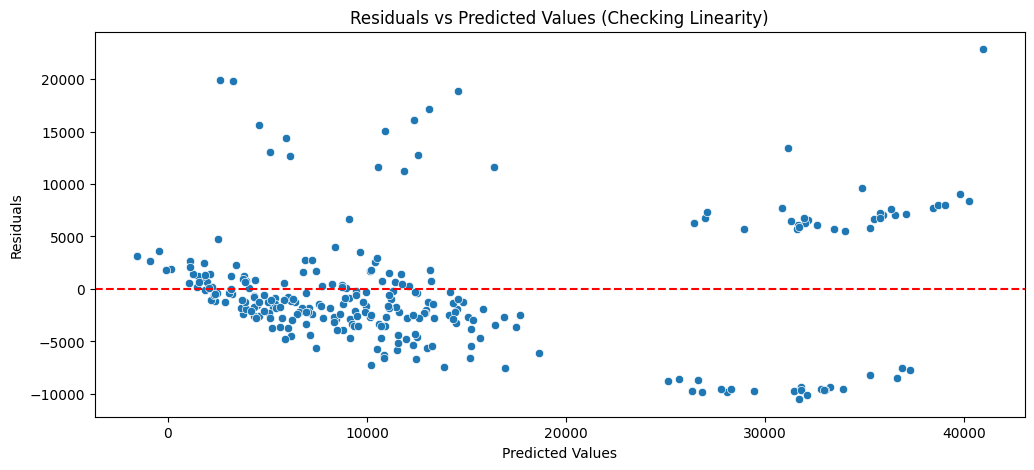

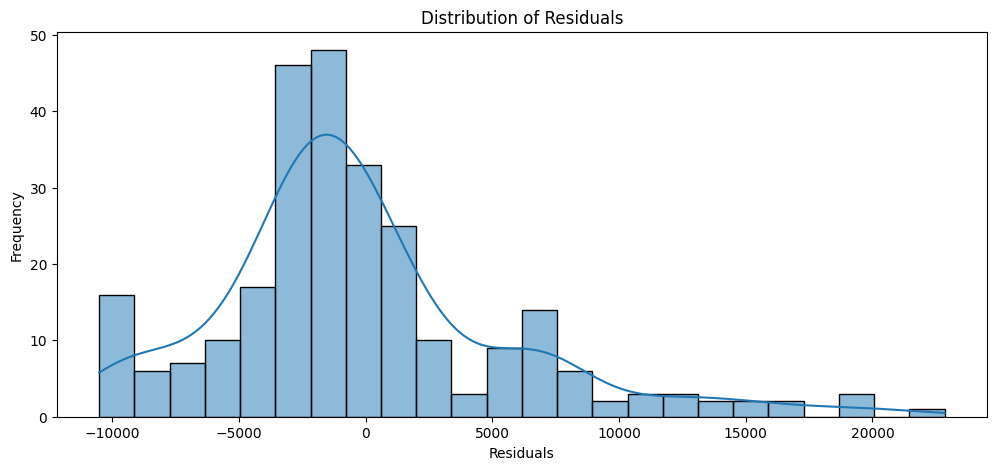

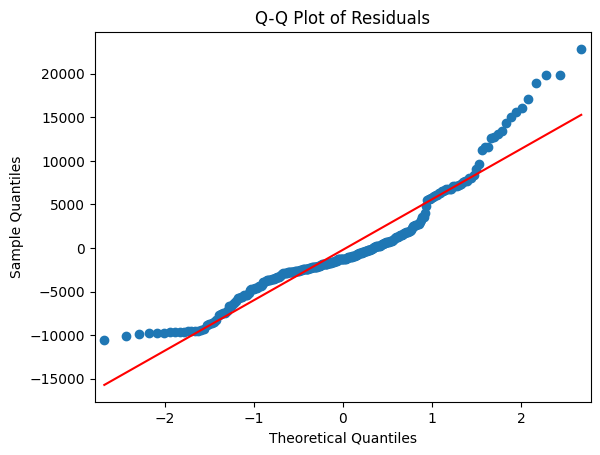

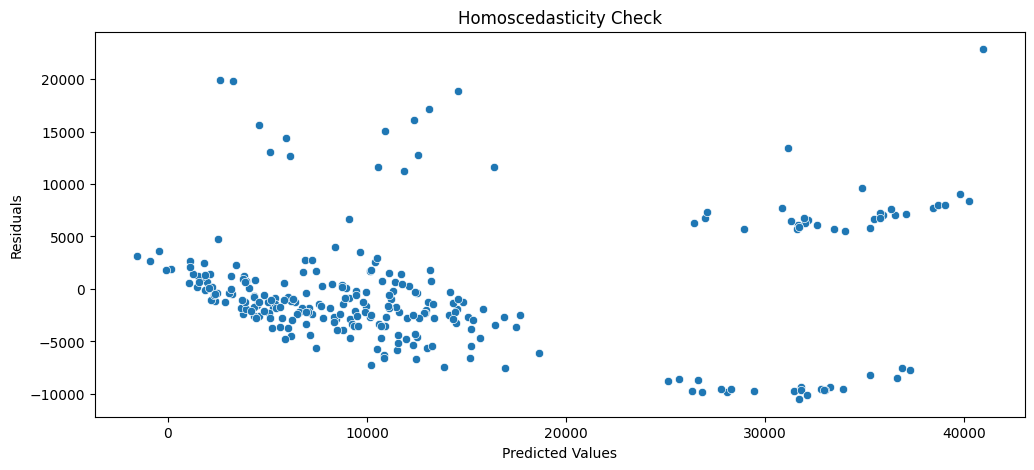


Variance Inflation Factor (VIF)

Variance Inflation Factor (VIF):
             VIF                          feature
2            inf         onehotencoder__smoker_no
3            inf        onehotencoder__smoker_yes
5   2.358448e+08  onehotencoder__region_northwest
4   8.212097e+07  onehotencoder__region_northeast
7   4.315386e+05  onehotencoder__region_southwest
0   1.172308e+05        onehotencoder__sex_female
1   1.617849e+04          onehotencoder__sex_male
6   6.722297e+03  onehotencoder__region_southeast
9   1.106606e+00              standardscaler__bmi
8   1.016718e+00              standardscaler__age
10  1.002878e+00         standardscaler__children

Durbin-Watson Statistic (Independence of Errors): 2.190540770682535
                            feature   coefficient
3         onehotencoder__smoker_yes  11825.564428
8               standardscaler__age   3614.975415
9               standardscaler__bmi   2036.228123
10         standardscaler__children    516.890247
4   onehotenco

d:\Machine Learning Projects\Medical Insurance Price Optimization\venv\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [29]:
model = linear_regression_diagnostics(df_feat, target="charges")